In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


curve_path = ROOT / "indexes" / "solmaz_curve_sift_W600p000_v13.csv"

df = pd.read_csv(curve_path)

print(df.columns.tolist())
print(df["SolmazMethod"].unique())


k_target = 100
curves = df[df["k"] == k_target].copy()

display(curves.head())

['SolmazDataset', 'SolmazMethod', 'k', 'T', 'efC', 'W', 'UpdateCount', 'ef', 'Recall', 'QPS', 'Time_ms']
<StringArray>
[                      'DAPG',                'PSEUDO_DAPG',
          'AWARE_PSEUDO_DAPG',         'ANCHOR_PSEUDO_DAPG',
 'LEARNED_ANCHOR_PSEUDO_DAPG',                   'LIGA_COL',
                'LSHAPG_BASE',                       'HNSW']
Length: 8, dtype: str


,SolmazDataset,SolmazMethod,k,T,efC,W,UpdateCount,ef,Recall,QPS,Time_ms
3232,sift,DAPG,100,24,80,600p000,200,100,0.8851,1812.81,0.55163
3233,sift,DAPG,100,24,80,600p000,200,120,0.9027,1570.52,0.63673
3234,sift,DAPG,100,24,80,600p000,200,140,0.9161,1394.64,0.71703
3235,sift,DAPG,100,24,80,600p000,200,160,0.9248,1245.76,0.80272
3236,sift,DAPG,100,24,80,600p000,200,180,0.9318,1151.19,0.86867


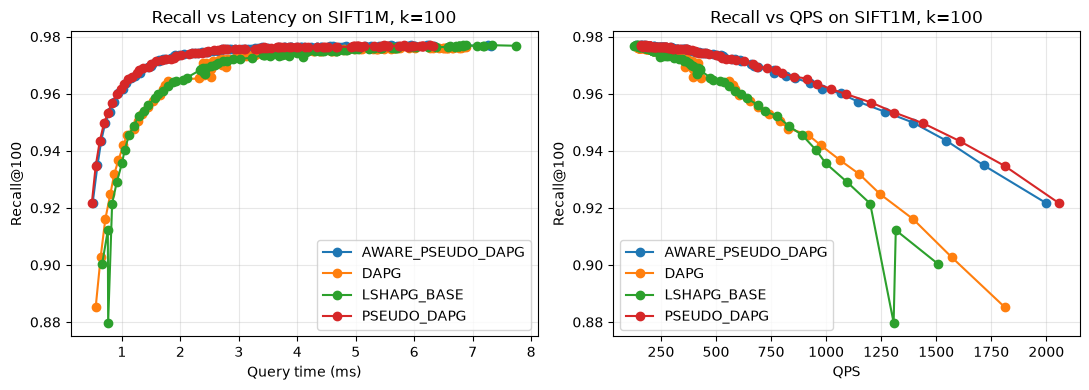

In [2]:
methods_to_plot = [
    "DAPG",
    "PSEUDO_DAPG",
    "AWARE_PSEUDO_DAPG",
    "LSHAPG_BASE",
]

plot_df = curves[curves["SolmazMethod"].isin(methods_to_plot)].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for method, g in plot_df.groupby("SolmazMethod"):
    g = g.sort_values("Time_ms")
    axes[0].plot(g["Time_ms"], g["Recall"], marker="o", label=method)

axes[0].set_title("Recall vs Latency on SIFT1M, k=100")
axes[0].set_xlabel("Query time (ms)")
axes[0].set_ylabel("Recall@100")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for method, g in plot_df.groupby("SolmazMethod"):
    g = g.sort_values("QPS")
    axes[1].plot(g["QPS"], g["Recall"], marker="o", label=method)

axes[1].set_title("Recall vs QPS on SIFT1M, k=100")
axes[1].set_xlabel("QPS")
axes[1].set_ylabel("Recall@100")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
ef_values = [100, 120, 140, 200, 300, 400, 600, 800, 1000, 1500, 2000, 2100]

ef_table = curves[
    (curves["SolmazMethod"].isin(methods_to_plot)) &
    (curves["ef"].isin(ef_values))
].copy()

ef_table = ef_table[
    ["SolmazMethod", "k", "ef", "Recall", "Time_ms", "QPS"]
].sort_values(["SolmazMethod", "ef"])

display(ef_table)


out_dir = ROOT / "github_tables"
out_dir.mkdir(exist_ok=True)

ef_table.to_csv(out_dir / "sift1m_k100_ef_sweep_table.csv", index=False)

with open(out_dir / "sift1m_k100_ef_sweep_table.md", "w", encoding="utf-8") as f:
    f.write(ef_table.to_markdown(index=False))



,SolmazMethod,k,ef,Recall,Time_ms,QPS
3434,AWARE_PSEUDO_DAPG,100,100,0.9218,0.50080,1996.810
3435,AWARE_PSEUDO_DAPG,100,120,0.9349,0.58278,1715.910
3436,AWARE_PSEUDO_DAPG,100,140,0.9436,0.64724,1545.020
3439,AWARE_PSEUDO_DAPG,100,200,0.9572,0.87291,1145.590
3444,AWARE_PSEUDO_DAPG,100,300,0.9662,1.22169,818.538
3449,AWARE_PSEUDO_DAPG,100,400,0.9704,1.51976,657.999
3459,AWARE_PSEUDO_DAPG,100,600,0.9741,2.19245,456.111
3469,AWARE_PSEUDO_DAPG,100,800,0.9756,2.77246,360.691
3479,AWARE_PSEUDO_DAPG,100,1000,0.9760,3.27340,305.493
3504,AWARE_PSEUDO_DAPG,100,1500,0.9765,4.80662,208.046
